In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference

from matplotlib.colors import ListedColormap, BoundaryNorm

c:\Users\comds\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
WORK_DIR = Path(r"C:\Users\comds\Desktop\졸업작품\vscode_script")

NSCLC_ROOT = Path(
    r"C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2"
)

NSCLC_IMAGE_ROOT = NSCLC_ROOT / "images"

MODEL_PATH = WORK_DIR / "best_t11_t12_3d_unet_D128_classwise.pth"

OUTPUT_ROOT = NSCLC_ROOT / "predictions_t11_t12_D128"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("NSCLC_IMAGE_ROOT exists:", NSCLC_IMAGE_ROOT.exists())
print("MODEL_PATH exists:", MODEL_PATH.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)

NSCLC_IMAGE_ROOT exists: True
MODEL_PATH exists: True
OUTPUT_ROOT: C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\predictions_t11_t12_D128


In [4]:
nsclc_files = sorted(NSCLC_IMAGE_ROOT.glob("*.nii.gz"))

print("n NSCLC files:", len(nsclc_files))

for p in nsclc_files[:10]:
    print(p.name)

n NSCLC files: 3
LUNG1-001.nii.gz
LUNG1-002.nii.gz
LUNG1-003.nii.gz


In [6]:
def apply_hu_window_and_normalize(image, lower=-1000, upper=2000):
    image = np.clip(image, lower, upper)
    image = (image - lower) / (upper - lower)
    return image.astype(np.float32)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [8]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

In [9]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
    )
)

model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [10]:
def load_nsclc_image(path):
    nii = nib.load(path)
    image = nii.get_fdata().astype(np.float32)

    image_norm = apply_hu_window_and_normalize(
        image,
        lower=-1000,
        upper=2000,
    )

    # nibabel image shape: [X, Y, Z]
    # model input shape: [B, C, D, H, W] = [1, 1, Z, Y, X]
    image_dhw = np.transpose(image_norm, (2, 1, 0))

    tensor = torch.from_numpy(image_dhw).unsqueeze(0).unsqueeze(0).float()

    return nii, image, image_norm, tensor

In [11]:
def predict_nsclc_volume(path, model, device):
    nii, image_hu, image_norm, tensor = load_nsclc_image(path)

    tensor = tensor.to(device)

    roi_size = (128, 192, 192)  # D, H, W
    sw_batch_size = 1

    with torch.no_grad():
        logits = sliding_window_inference(
            inputs=tensor,
            roi_size=roi_size,
            sw_batch_size=sw_batch_size,
            predictor=model,
            overlap=0.5,
            mode="gaussian",
        )

        pred_dhw = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)

    # [D, H, W] -> [X, Y, Z]
    pred_xyz = np.transpose(pred_dhw, (2, 1, 0))

    return {
        "nii": nii,
        "image_hu": image_hu,
        "image_norm": image_norm,
        "pred_xyz": pred_xyz,
    }

In [12]:
def save_prediction_nifti(pred_xyz, reference_nii, output_path):
    pred_nii = nib.Nifti1Image(
        pred_xyz.astype(np.uint8),
        affine=reference_nii.affine,
        header=reference_nii.header,
    )

    pred_nii.set_data_dtype(np.uint8)

    nib.save(pred_nii, output_path)

In [13]:
def show_nsclc_prediction_overlay(image_hu, pred_xyz, file_name, window=(-1000, 2000)):
    """
    pred label:
      0 = background
      1 = T11
      2 = T12

    display color:
      yellow = T11
      lime = T12
    """

    pred_mask = pred_xyz > 0

    if not pred_mask.any():
        print("No T11/T12 prediction:", file_name)
        return

    image_vis = np.clip(image_hu, window[0], window[1])
    image_vis = (image_vis - window[0]) / (window[1] - window[0])

    coords = np.argwhere(pred_mask)
    x_min, y_min, z_min = coords.min(axis=0)
    x_max, y_max, z_max = coords.max(axis=0)

    x_center = int((x_min + x_max) / 2)
    y_center = int((y_min + y_max) / 2)
    z_center = int((z_min + z_max) / 2)

    cmap_pred = ListedColormap(["yellow", "lime"])
    norm_pred = BoundaryNorm([0.5, 1.5, 2.5], cmap_pred.N)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(file_name, fontsize=12)

    # axial: [X, Y] at Z
    axes[0].imshow(image_vis[:, :, z_center].T, cmap="gray", origin="lower")
    axes[0].imshow(
        np.ma.masked_where(pred_xyz[:, :, z_center].T == 0, pred_xyz[:, :, z_center].T),
        cmap=cmap_pred,
        norm=norm_pred,
        alpha=0.55,
        origin="lower",
    )
    axes[0].set_title(f"Axial z={z_center}")

    # coronal: [X, Z] at Y
    axes[1].imshow(image_vis[:, y_center, :].T, cmap="gray", origin="lower")
    axes[1].imshow(
        np.ma.masked_where(pred_xyz[:, y_center, :].T == 0, pred_xyz[:, y_center, :].T),
        cmap=cmap_pred,
        norm=norm_pred,
        alpha=0.55,
        origin="lower",
    )
    axes[1].set_title(f"Coronal y={y_center}")

    # sagittal: [Y, Z] at X
    axes[2].imshow(image_vis[x_center, :, :].T, cmap="gray", origin="lower")
    axes[2].imshow(
        np.ma.masked_where(pred_xyz[x_center, :, :].T == 0, pred_xyz[x_center, :, :].T),
        cmap=cmap_pred,
        norm=norm_pred,
        alpha=0.55,
        origin="lower",
    )
    axes[2].set_title(f"Sagittal x={x_center}")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("prediction labels:", np.unique(pred_xyz))
    print("pred voxel count T11:", np.sum(pred_xyz == 1))
    print("pred voxel count T12:", np.sum(pred_xyz == 2))
    print("pred bbox xyz:")
    print("x:", x_min, "-", x_max)
    print("y:", y_min, "-", y_max)
    print("z:", z_min, "-", z_max)

In [15]:
sample_files = nsclc_files[:3]

for path in sample_files:
    print("=" * 80)
    print("Inference:", path.name)

    result = predict_nsclc_volume(
        path=path,
        model=model,
        device=device,
    )

    output_path = OUTPUT_ROOT / path.name.replace(
        ".nii.gz",
        "_pred_t11_t12_D128.nii.gz",
    )

    save_prediction_nifti(
        pred_xyz=result["pred_xyz"],
        reference_nii=result["nii"],
        output_path=output_path,
    )

    print("saved:", output_path)

    show_nsclc_prediction_overlay(
        image_hu=result["image_hu"],
        pred_xyz=result["pred_xyz"],
        file_name=path.name,
    )

In [16]:
print("NSCLC_ROOT:", NSCLC_ROOT)
print("NSCLC_IMAGE_ROOT:", NSCLC_IMAGE_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

print("NSCLC_ROOT exists:", NSCLC_ROOT.exists())
print("NSCLC_IMAGE_ROOT exists:", NSCLC_IMAGE_ROOT.exists())
print("OUTPUT_ROOT exists:", OUTPUT_ROOT.exists())

NSCLC_ROOT: C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2
NSCLC_IMAGE_ROOT: C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\images
OUTPUT_ROOT: C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\predictions_t11_t12_D128
NSCLC_ROOT exists: True
NSCLC_IMAGE_ROOT exists: True
OUTPUT_ROOT exists: True


In [17]:
print("files directly under NSCLC_ROOT:")
for p in sorted(NSCLC_ROOT.glob("*")):
    print(p.name)

files directly under NSCLC_ROOT:
images
nsclc_intensity_sample.csv
nsclc_manifest.csv
nsclc_manifest.pkl
nsclc_manifest_summary.json
nsclc_resample_log.csv
nsclc_resample_log.pkl
predictions_t11_t12_D128


In [18]:
print("files under NSCLC_IMAGE_ROOT:")
for p in sorted(NSCLC_IMAGE_ROOT.glob("*")):
    print(p.name)

files under NSCLC_IMAGE_ROOT:
LUNG1-001.nii.gz
LUNG1-002.nii.gz
LUNG1-003.nii.gz


In [19]:
nsclc_files = sorted(NSCLC_IMAGE_ROOT.glob("*.nii.gz"))

print("n nsclc_files:", len(nsclc_files))
for p in nsclc_files:
    print(p)

n nsclc_files: 3
C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\images\LUNG1-001.nii.gz
C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\images\LUNG1-002.nii.gz
C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\images\LUNG1-003.nii.gz


In [20]:
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("output files before inference:")
for p in sorted(OUTPUT_ROOT.glob("*")):
    print(p.name)

output files before inference:


In [25]:
path = nsclc_files[2]

print("Inference:", path)
print("exists:", path.exists())

result = predict_nsclc_volume(
    path=path,
    model=model,
    device=device,
)

output_path = OUTPUT_ROOT / path.name.replace(
    ".nii.gz",
    "_pred_t11_t12_D128.nii.gz",
)

save_prediction_nifti(
    pred_xyz=result["pred_xyz"],
    reference_nii=result["nii"],
    output_path=output_path,
)

print("saved path:", output_path)
print("saved exists:", output_path.exists())
print("pred unique:", np.unique(result["pred_xyz"]))

Inference: C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\images\LUNG1-003.nii.gz
exists: True
saved path: C:\Users\comds\Desktop\졸업작품\dataset\NSCLC LUNG CANCER\nsclc_resampled_1x1x2\predictions_t11_t12_D128\LUNG1-003_pred_t11_t12_D128.nii.gz
saved exists: True
pred unique: [0 1 2]


In [26]:
pred_files = sorted(OUTPUT_ROOT.glob("*.nii.gz"))

print("n prediction files:", len(pred_files))
for p in pred_files:
    print(p.name)

n prediction files: 3
LUNG1-001_pred_t11_t12_D128.nii.gz
LUNG1-002_pred_t11_t12_D128.nii.gz
LUNG1-003_pred_t11_t12_D128.nii.gz


In [27]:
def show_saved_nsclc_prediction_overlay(image_path, pred_path, window=(-1000, 2000)):
    image_nii = nib.load(image_path)
    pred_nii = nib.load(pred_path)

    image_hu = image_nii.get_fdata().astype(np.float32)
    pred_xyz = np.asanyarray(pred_nii.dataobj).astype(np.uint8)

    image_vis = np.clip(image_hu, window[0], window[1])
    image_vis = (image_vis - window[0]) / (window[1] - window[0])

    pred_mask = pred_xyz > 0

    if not pred_mask.any():
        print("No prediction:", pred_path.name)
        return

    coords = np.argwhere(pred_mask)
    x_min, y_min, z_min = coords.min(axis=0)
    x_max, y_max, z_max = coords.max(axis=0)

    x_center = int((x_min + x_max) / 2)
    y_center = int((y_min + y_max) / 2)
    z_center = int((z_min + z_max) / 2)

    cmap_pred = ListedColormap(["yellow", "lime"])
    norm_pred = BoundaryNorm([0.5, 1.5, 2.5], cmap_pred.N)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(pred_path.name, fontsize=12)

    # axial
    axes[0].imshow(image_vis[:, :, z_center].T, cmap="gray", origin="lower")
    axes[0].imshow(
        np.ma.masked_where(pred_xyz[:, :, z_center].T == 0, pred_xyz[:, :, z_center].T),
        cmap=cmap_pred,
        norm=norm_pred,
        alpha=0.55,
        origin="lower",
    )
    axes[0].set_title(f"Axial z={z_center}")

    # coronal
    axes[1].imshow(image_vis[:, y_center, :].T, cmap="gray", origin="lower")
    axes[1].imshow(
        np.ma.masked_where(pred_xyz[:, y_center, :].T == 0, pred_xyz[:, y_center, :].T),
        cmap=cmap_pred,
        norm=norm_pred,
        alpha=0.55,
        origin="lower",
    )
    axes[1].set_title(f"Coronal y={y_center}")

    # sagittal
    axes[2].imshow(image_vis[x_center, :, :].T, cmap="gray", origin="lower")
    axes[2].imshow(
        np.ma.masked_where(pred_xyz[x_center, :, :].T == 0, pred_xyz[x_center, :, :].T),
        cmap=cmap_pred,
        norm=norm_pred,
        alpha=0.55,
        origin="lower",
    )
    axes[2].set_title(f"Sagittal x={x_center}")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("image shape:", image_hu.shape)
    print("pred shape:", pred_xyz.shape)
    print("pred unique:", np.unique(pred_xyz))
    print("T11 voxels:", np.sum(pred_xyz == 1))
    print("T12 voxels:", np.sum(pred_xyz == 2))
    print("bbox x:", x_min, "-", x_max)
    print("bbox y:", y_min, "-", y_max)
    print("bbox z:", z_min, "-", z_max)

image: LUNG1-001.nii.gz
pred: LUNG1-001_pred_t11_t12_D128.nii.gz
image exists: True


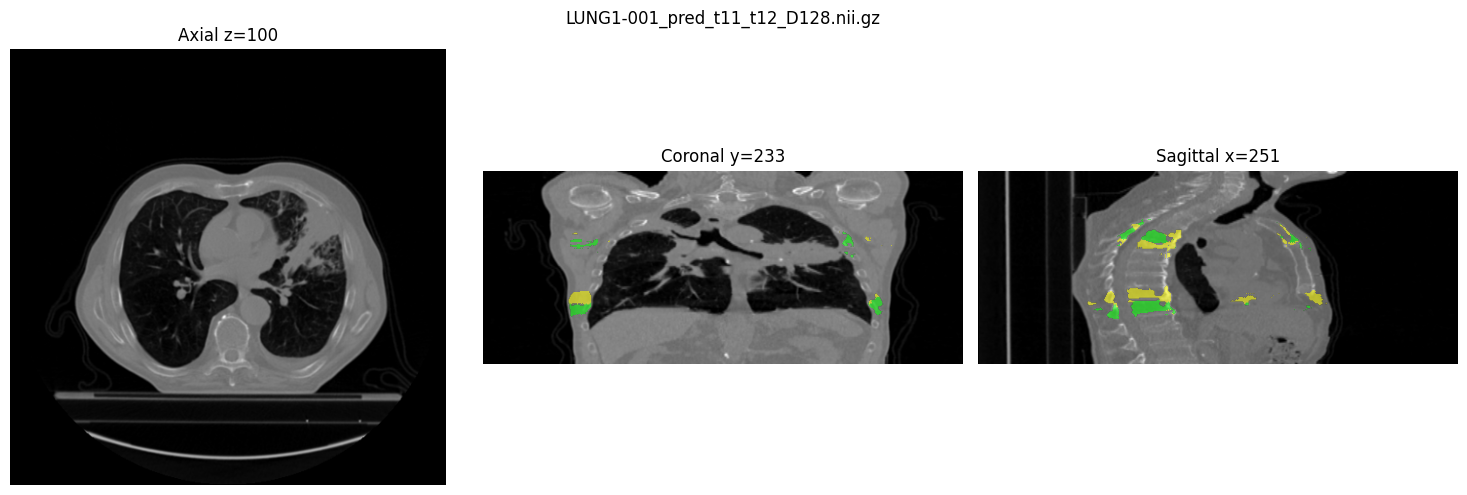

image shape: (500, 500, 201)
pred shape: (500, 500, 201)
pred unique: [0 1 2]
T11 voxels: 216380
T12 voxels: 298093
bbox x: 59 - 443
bbox y: 40 - 427
bbox z: 0 - 200
image: LUNG1-002.nii.gz
pred: LUNG1-002_pred_t11_t12_D128.nii.gz
image exists: True


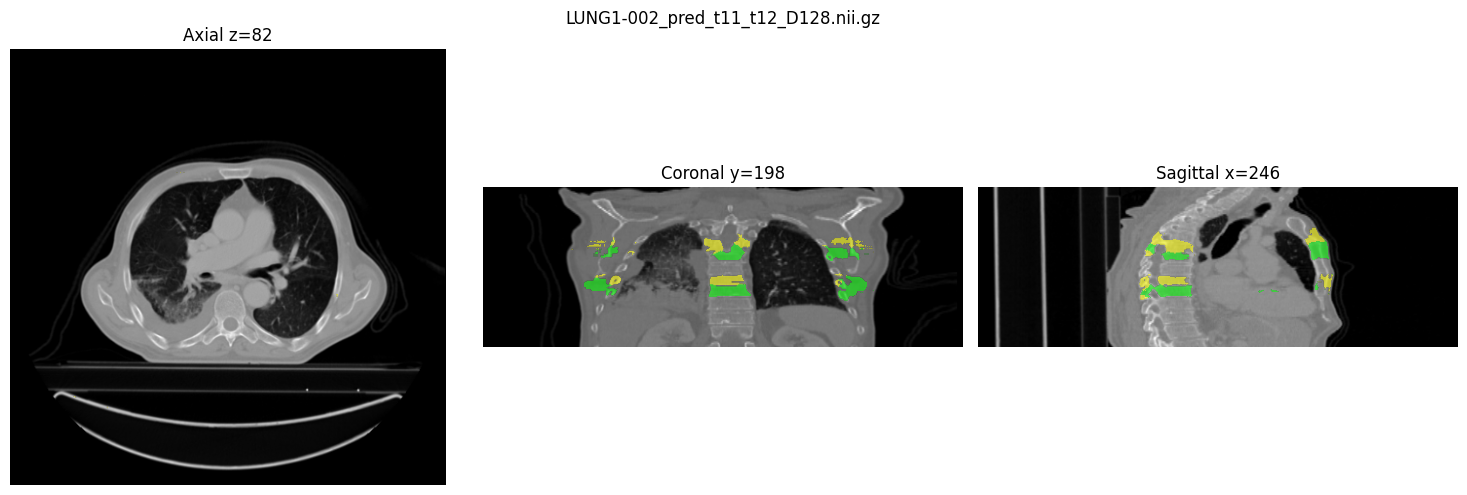

image shape: (500, 500, 166)
pred shape: (500, 500, 166)
pred unique: [0 1 2]
T11 voxels: 175061
T12 voxels: 248235
bbox x: 46 - 447
bbox y: 23 - 374
bbox z: 0 - 165
image: LUNG1-003.nii.gz
pred: LUNG1-003_pred_t11_t12_D128.nii.gz
image exists: True


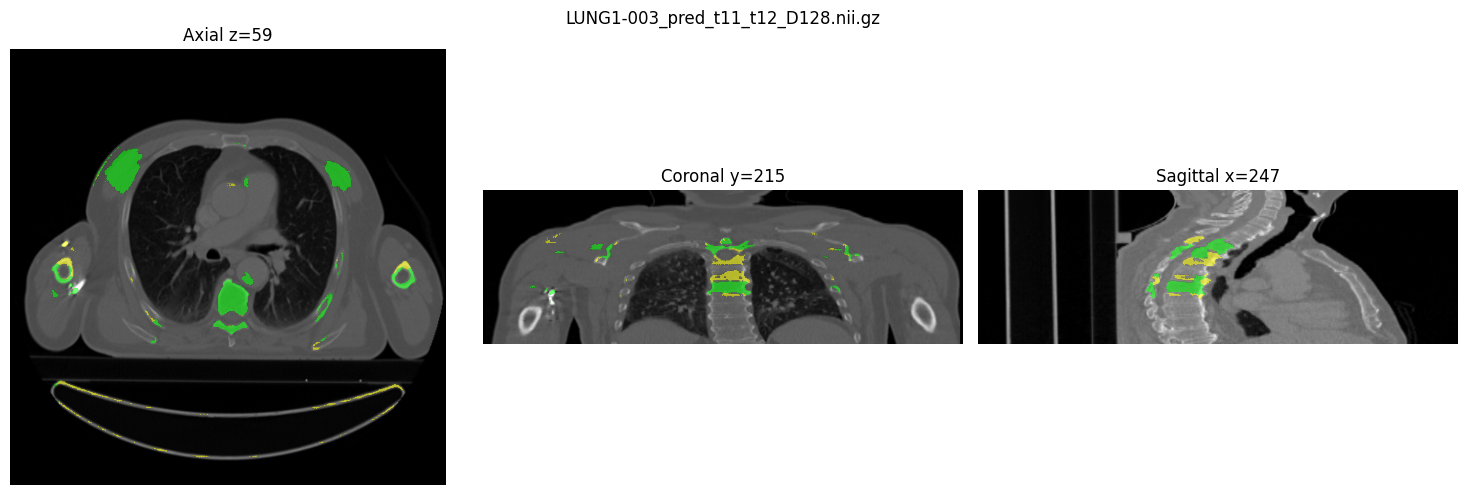

image shape: (500, 500, 160)
pred shape: (500, 500, 160)
pred unique: [0 1 2]
T11 voxels: 100303
T12 voxels: 132782
bbox x: 30 - 464
bbox y: 31 - 400
bbox z: 0 - 118


In [28]:
for pred_path in pred_files:
    image_name = pred_path.name.replace(
        "_pred_t11_t12_D128.nii.gz",
        ".nii.gz",
    )

    image_path = NSCLC_IMAGE_ROOT / image_name

    if not image_path.exists():
        image_path = NSCLC_ROOT / image_name

    print("=" * 80)
    print("image:", image_path.name)
    print("pred:", pred_path.name)
    print("image exists:", image_path.exists())

    show_saved_nsclc_prediction_overlay(
        image_path=image_path,
        pred_path=pred_path,
    )

학습모델은 CTSpine1K가 crop된 volume을 가지고 학습을 시켰기 때문에 crop이 안된 NSCLC volume에 추론을 했을때 prediction이 여러 장기에 너무 넓게 퍼지고 여러 구조에 흩어져 있는 문제 발생

따라서 NSCLC도 crop과정을 거치고 다시 추론해야 함.

하지만 CTSpine1K는 T11/T12 GT label을 기준으로 crop을 하였지만 NSCLC는 T11/T12 GT label이 없으므로 T11/T12 중심을 어떻게 찾아 crop할지 결정해야 함
